# Unemployment Analysis in India — CodeAlpha Data Science Internship
## Task 2: Unemployment Analysis with Python
### Moageledi Mafhoko
**Environment:** `myenv` (Anaconda) · VS Code
**Datasets:** `Unemployment_in_India.csv` · `Unemployment_Rate_upto_11_2020.csv`

---

### Notebook Roadmap

| Step | Section | What to do |
|------|----------|------------|
| 1 | Setup | Import libraries, set plot style |
| 2 | Data Cleaning | Load, fix column names, missing values, whitespace, date formats, duplicates |
| 3 | Exploratory Data Analysis (EDA) | Summary stats, unemployment over time, region comparisons |
| 4 | Covid Impact | Before vs. during Covid comparison |
| 5 | Insights | Written findings connecting data to real-world policy

---
## Step 1 — 


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# plot consistency throughout
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 5)

---
## Step 2 — Data Cleaning


In [41]:
# 2.1  Load datasets
df1 = pd.read_csv('Unemployment in India.csv')
df2 = pd.read_csv('Unemployment_Rate_upto_11_2020.csv')

print('Dataset 1 (pre/mid-2020):', df1.shape)
print('Dataset 2 (up to Nov 2020):', df2.shape)

df1.head()

Dataset 1 (pre/mid-2020): (754, 7)
Dataset 2 (up to Nov 2020): (267, 9)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [42]:
# Column names
print(df1.columns.tolist())
print(df2.columns.tolist())

['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


In [43]:
# 2.2  Clean column names (trailing whitespaces)
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

print(df1.columns.tolist())
print(df2.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


In [44]:
# 2.3  Dataset 2 has two 'Region' columns — the second is actually a zone label ─
df2.head(3)
# 2.4  Rename 'Region.1' to 'Zone' for clarity 
df2.rename(columns={'Region.1': 'Zone'}, inplace=True)
df2.columns.tolist()

['Region',
 'Date',
 'Frequency',
 'Estimated Unemployment Rate (%)',
 'Estimated Employed',
 'Estimated Labour Participation Rate (%)',
 'Zone',
 'longitude',
 'latitude']

### 2.5 Stripping whitespace from text values

In [45]:
# 2.5  Strip whitespace from all text/object columns ───────────────────────────
for df in (df1, df2):
    text_cols = df.select_dtypes(include='object').columns
    for c in text_cols:
        df[c] = df[c].str.strip()

df1['Area'].unique(), df2['Zone'].unique()

(<StringArray>
 ['Rural', nan, 'Urban']
 Length: 3, dtype: str,
 <StringArray>
 ['South', 'Northeast', 'East', 'West', 'North']
 Length: 5, dtype: str)

In [46]:
# 2.6  Check for missing values ────────────────────────────────────────────────
print('=== Dataset 1 missing values ===')
print(df1.isnull().sum())
print('\n=== Dataset 2 missing values ===')
print(df2.isnull().sum())

=== Dataset 1 missing values ===
Region                                     14
Date                                       14
Frequency                                  14
Estimated Unemployment Rate (%)            14
Estimated Employed                         14
Estimated Labour Participation Rate (%)    14
Area                                       14
dtype: int64

=== Dataset 2 missing values ===
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Zone                                       0
longitude                                  0
latitude                                   0
dtype: int64


In [47]:
# 2.7  Drop rows that are entirely empty (all 14 missing values line up on the same rows) ─
df1.dropna(how='all', inplace=True)

print('Dataset 1 shape after dropping empty rows:', df1.shape)
print(df1.isnull().sum())

Dataset 1 shape after dropping empty rows: (740, 7)
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64


In [48]:
# 2.8  Convert Date to real datetime, and rate/employment columns to numeric ───
for df in (df1, df2):
    df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')
    df['Estimated Unemployment Rate (%)'] = pd.to_numeric(df['Estimated Unemployment Rate (%)'], errors='coerce')
    df['Estimated Employed'] = pd.to_numeric(df['Estimated Employed'], errors='coerce')
    df['Estimated Labour Participation Rate (%)'] = pd.to_numeric(df['Estimated Labour Participation Rate (%)'], errors='coerce')

print(df1.dtypes)
print()
print(df2.dtypes)

Region                                                str
Date                                       datetime64[us]
Frequency                                             str
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                                  str
dtype: object

Region                                                str
Date                                       datetime64[us]
Frequency                                             str
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                  int64
Estimated Labour Participation Rate (%)           float64
Zone                                                  str
longitude                                         float64
latitude                                          float64
dtype: object


In [49]:
# 2.9  Check and remove duplicate rows ──────────────────────────────────────────
print('Duplicates in df1:', df1.duplicated().sum())
print('Duplicates in df2:', df2.duplicated().sum())

df1.drop_duplicates(inplace=True)
df2.drop_duplicates(inplace=True)

print('Shapes after dedup:', df1.shape, df2.shape)

Duplicates in df1: 0
Duplicates in df2: 0
Shapes after dedup: (740, 7) (267, 9)


---
## Step 3 — Combining Datasets into One Continuous Timeline

Dataset 1 and Dataset 2 overlap in time but have different structures (Rural/Urban split vs.
Zone/geo split). To get one clean national trend line from mid-2019 through Nov 2020, we
collapse each dataset down to a single national average unemployment rate per date, then
combine them.

In [50]:
# 3.1  Collapse Dataset 1 to one national average unemployment rate per date ──
national_1 = df1.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()
national_1['Source'] = 'Dataset 1'

national_1.head()

,Date,Estimated Unemployment Rate (%),Source
0,2019-05-31,8.874259,Dataset 1
1,2019-06-30,9.303333,Dataset 1
2,2019-07-31,9.033889,Dataset 1
3,2019-08-31,9.637925,Dataset 1
4,2019-09-30,9.051731,Dataset 1


In [51]:
# 3.2  Collapse Dataset 2 to one national average unemployment rate per date ──
national_2 = df2.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()
national_2['Source'] = 'Dataset 2'

national_2.head()

,Date,Estimated Unemployment Rate (%),Source
0,2020-01-31,9.196538,Dataset 2
1,2020-02-29,9.266154,Dataset 2
2,2020-03-31,10.782593,Dataset 2
3,2020-04-30,22.236154,Dataset 2
4,2020-05-31,23.244444,Dataset 2


In [52]:
# 3.3  Check the full date range of each dataset before combining ──────────────
print('Dataset 1 date range:', national_1['Date'].min(), 'to', national_1['Date'].max())
print('Dataset 2 date range:', national_2['Date'].min(), 'to', national_2['Date'].max())

Dataset 1 date range: 2019-05-31 00:00:00 to 2020-06-30 00:00:00
Dataset 2 date range: 2020-01-31 00:00:00 to 2020-10-31 00:00:00


In [53]:
# 3.4  Keep Dataset 1 only where it doesn't overlap with Dataset 2 ──────────────
cutoff = pd.Timestamp('2020-01-01')

national_1_unique = national_1[national_1['Date'] < cutoff]

# Combine: pre-2020 from Dataset 1, Jan 2020 onward from Dataset 2
national_combined = pd.concat([national_1_unique, national_2], ignore_index=True)
national_combined = national_combined.sort_values('Date').reset_index(drop=True)

print(national_combined.shape)
national_combined.head(10)

(18, 3)


,Date,Estimated Unemployment Rate (%),Source
0,2019-05-31,8.874259,Dataset 1
1,2019-06-30,9.303333,Dataset 1
2,2019-07-31,9.033889,Dataset 1
3,2019-08-31,9.637925,Dataset 1
4,2019-09-30,9.051731,Dataset 1
5,2019-10-31,9.900909,Dataset 1
6,2019-11-30,9.868364,Dataset 1
7,2019-12-31,9.497358,Dataset 1
8,2020-01-31,9.196538,Dataset 2
9,2020-02-29,9.266154,Dataset 2


---
## Step 3 — Exploratory Data Analysis (EDA)

With clean, combined data in hand, let's look at basic statistics and compare
unemployment across states and between rural/urban areas.

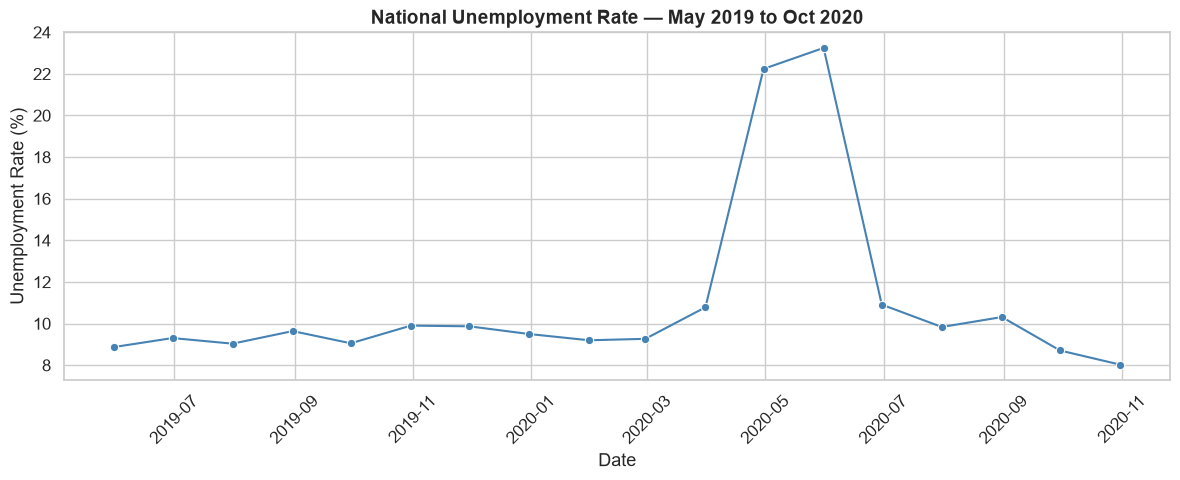

In [54]:
# 3.5  Plot the combined national unemployment trend ────────────────────────────
plt.figure(figsize=(12, 5))
sns.lineplot(data=national_combined, x='Date', y='Estimated Unemployment Rate (%)', marker='o', color='steelblue')
plt.title('National Unemployment Rate — May 2019 to Oct 2020', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## Step 4 — Before vs. During Covid-19 Comparison

India's nationwide lockdown began March 25, 2020. We split the combined timeline at
that point to quantify the impact.

In [55]:
# 4.1  Label each row as Before or During Covid ─────────────────────────────────
lockdown_start = pd.Timestamp('2020-03-25')

national_combined['Period'] = np.where(
    national_combined['Date'] < lockdown_start, 'Before Covid', 'During Covid'
)

period_avg = national_combined.groupby('Period')['Estimated Unemployment Rate (%)'].mean()
print(period_avg.round(2))

Period
Before Covid     9.36
During Covid    13.01
Name: Estimated Unemployment Rate (%), dtype: float64


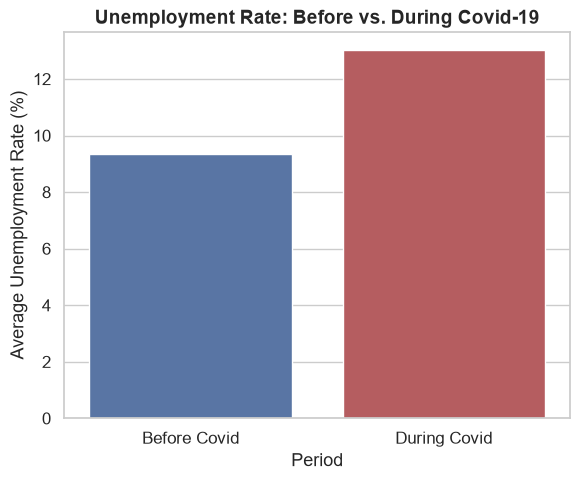

In [56]:
# 4.2  Visual before/during comparison ──────────────────────────────────────────
plt.figure(figsize=(6, 5))
sns.barplot(x=period_avg.index, y=period_avg.values, palette=['#4C72B0', '#C44E52'])
plt.title('Unemployment Rate: Before vs. During Covid-19', fontsize=14, fontweight='bold')
plt.ylabel('Average Unemployment Rate (%)')
plt.tight_layout()
plt.show()

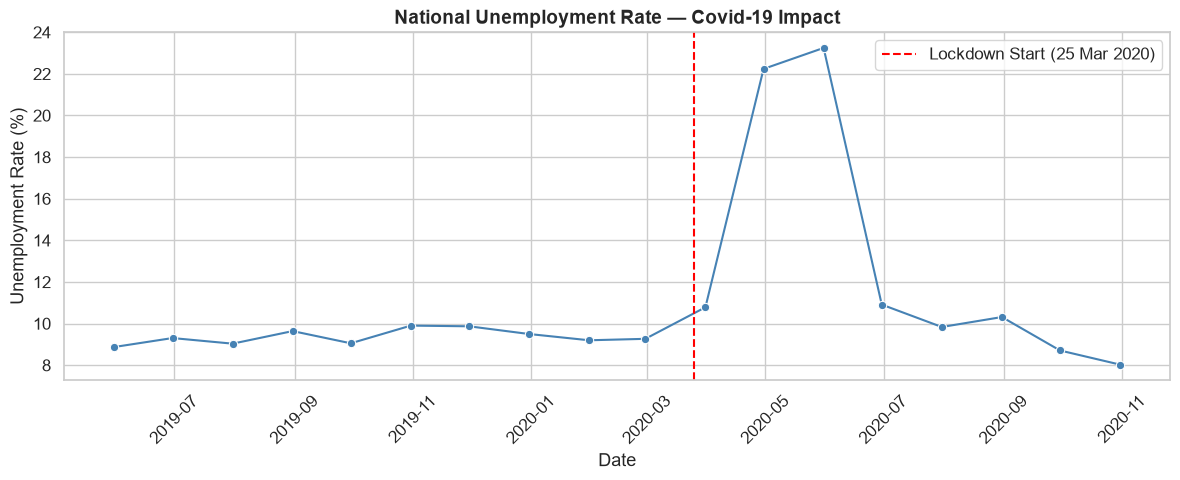

In [57]:
# 4.3  Timeline with lockdown marker ────────────────────────────────────────────
plt.figure(figsize=(12, 5))
sns.lineplot(data=national_combined, x='Date', y='Estimated Unemployment Rate (%)', marker='o', color='steelblue')
plt.axvline(lockdown_start, color='red', linestyle='--', label='Lockdown Start (25 Mar 2020)')
plt.title('National Unemployment Rate — Covid-19 Impact', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [58]:
# 3.6  Basic summary statistics ─────────────────────────────────────────────────
print('=== Dataset 1: Estimated Unemployment Rate (%) ===')
print(df1['Estimated Unemployment Rate (%)'].describe().round(2))

=== Dataset 1: Estimated Unemployment Rate (%) ===
count    740.00
mean      11.79
std       10.72
min        0.00
25%        4.66
50%        8.35
75%       15.89
max       76.74
Name: Estimated Unemployment Rate (%), dtype: float64


### What do these numbers mean?

- **Average: 11.79%** — in a typical month, about 12 in every 100 working-age people
  were unemployed.
- **Median: 8.35%** — the "middle" reading is lower than the average, meaning a few
  extreme months are pulling the average up.
- **Most months fall between 4.66% and 15.89%** — that's the normal range.
- **Range: 0% to 76.74%** — some states/months were near full employment; others saw
  over three-quarters of the workforce unemployed. That extreme is almost certainly a
  Covid lockdown spike.
- **Spread is large (10.72)** — the numbers bounce around a lot rather than staying steady.

**Takeaway:** unemployment was usually in a normal range, but a few extreme spikes( Covid-related) drag the average up. The next chart shows which states drove those spikes.

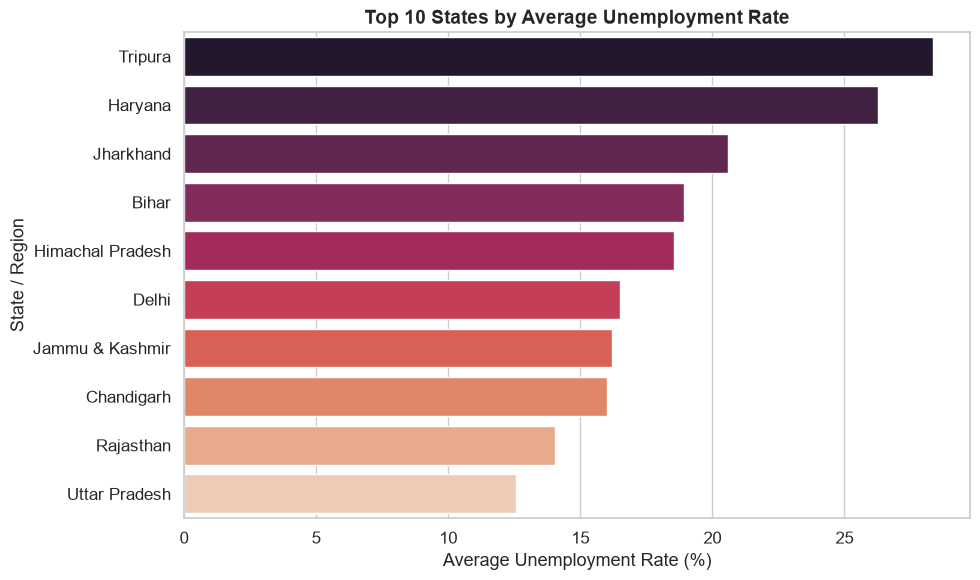

In [59]:
# 3.7  Compare unemployment rate by state (top 10, average across all dates) ────
region_avg = df1.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=region_avg.values, y=region_avg.index, palette='rocket')
plt.title('Top 10 States by Average Unemployment Rate', fontsize=14, fontweight='bold')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State / Region')
plt.tight_layout()
plt.show()

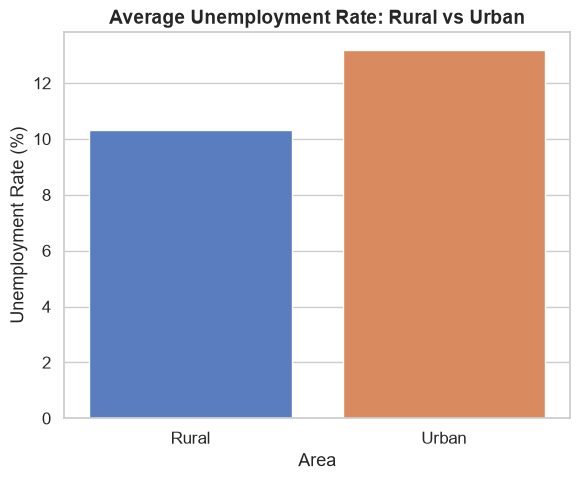

In [60]:
# 3.8  Compare average unemployment rate: Rural vs Urban ───────────────────────
area_avg = df1.groupby('Area')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(6, 5))
sns.barplot(x=area_avg.index, y=area_avg.values, palette='muted')
plt.title('Average Unemployment Rate: Rural vs Urban', fontsize=14, fontweight='bold')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.show()

---
## Step 5 — Written Insights

1. **Overall trend:** The national average unemployment rate was **9.36%** before the
   Covid-19 lockdown and rose to **13.01%** during and after it — an increase of about
   **3.65 percentage points**. At its peak (April–June 2020), the rate spiked as high
   as **~23%**, before gradually declining back toward pre-Covid levels by October 2020.

2. **Hardest-hit regions:** **Tripura (~28%)** and **Haryana (~26%)** recorded the highest
   average unemployment rates, followed by Jharkhand, Bihar, and Himachal Pradesh
   (all in the high teens to low 20s). These states likely faced a combination of
   migrant labour disruption, industrial slowdown, and limited informal-sector fallback
   options during the lockdown.

3. **Rural vs. Urban:** Urban areas averaged a higher unemployment rate (**~13%**) than
   rural areas (**~10%**). This likely reflects urban jobs being more dependent on
   offices, retail, and in-person services — all hit hard by lockdown restrictions —
   while rural workers had more access to agricultural work as a fallback.

4. **Recovery pattern:** After peaking around May–June 2020, the unemployment rate
   declined steadily through October 2020, approaching (though not fully returning to)
   pre-Covid levels — suggesting a real but incomplete economic recovery within the
   observed window.

5. **Policy implications:** These patterns suggest that future economic shocks could be
   softened by: (a) targeted relief for the hardest-hit states like Tripura and Haryana,
   (b) stronger safety nets for urban informal and service-sector workers, and
   (c) monitoring rural areas closely too, since their lower averages may mask
   vulnerability if agricultural fallback options are disrupted in future crises.